# Prepare the Data

## The Model Sand Dataset Stucture from teh training

In [1]:
from RNN_Sentence_Models import *

## The Settings

In [2]:
import torch
import os
if torch.cuda.is_available():
    #### Run on Gogle Colab
    # !pip install torch-ort
    # !python -m torch_ort.configure
    !python -m pip install lightning
    !python -m pip install transformers
    pin_memory = False
    num_workers = os.cpu_count() - 2 if os.cpu_count() -2 > 3 else 3

    device = torch.device("cuda")
    accelerator = "gpu"


    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = "/content/drive/MyDrive/Colab Data/RetrievalModel"
    # root_dir = "./drive/MyDrive/Colab Data/ResidualNeuralNetwork"
    torch.cuda.memory.empty_cache()
else:
    ### Run on my personal tower
    device = torch.device("cpu")
    accelerator = "cpu"
    data_dir = "EmbeddedData"
    # root_dir = "."


torch.set_float32_matmul_precision("medium")
os.makedirs(f"Training_Progress/Logs/{Project_Name}", exist_ok = True)
os.makedirs(f"Training_Progress/Checkpoints/{Project_Name}", exist_ok = True)

## Build the Dataloader for pytorch_lighnign test

In [3]:
import numpy as np
import pandas as pd

Large_Dataset = pd.read_parquet(f"{data_dir}/SentenceEmbedding.parquet")


from sklearn import preprocessing
le = preprocessing.LabelEncoder()
targets = le.fit_transform(Large_Dataset.esci_label.to_numpy())
Large_Dataset["esci_label_encoded"] = targets

labels, class_counts = np.unique(Large_Dataset.esci_label, return_counts = True)
total_samples = len(Large_Dataset.esci_label)
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights / np.sum(class_weights)).type(torch.float)

encoding_to_label_dict = {encoding: label for encoding, label in enumerate(labels)}

Large_Dataset_Test = Large_Dataset.loc[Large_Dataset.split == "test", :].drop(columns = [("split", "")])

SentenceEmbedding_Test = Dataset_SentenceEmbedding(Large_Dataset_Test)
batch_size = 256#  if torch.cuda.is_available() else 16

if torch.cuda.is_available():
    SentenceEmbedding_Test = DataLoader(SentenceEmbedding_Test, batch_size = batch_size, shuffle = False, pin_memory=pin_memory)
else:
    SentenceEmbedding_Test = DataLoader(SentenceEmbedding_Test, batch_size = batch_size, shuffle = False, pin_memory=False)

In [4]:
Large_Dataset_Test

product_title                                                       \
                    0          1         2          3         4          5   
104         19.782125 -20.849241  6.912220   8.974546  2.222180  12.317185   
105         19.782125 -20.849241  6.912220   8.974546  2.222180  12.317185   
106         13.794383 -19.057865  6.026787   3.129192  1.971212  11.096588   
107          3.686759  -6.699598  0.070188  16.677197  0.953404  -3.212091   
108         -4.444930  -6.306578 -4.463382   2.366049  2.559024  -0.128045   
...               ...        ...       ...        ...       ...        ...   
2621265     -0.443321  -0.105362 -2.251524   1.220237 -2.371012   3.012539   
2621268     -0.443321  -0.105362 -2.251524   1.220237 -2.371012   3.012539   
2621270      5.173185   1.389299 -2.997925  -0.967095 -2.599024   0.944685   
2621278      4.172548   3.149167 -3.231992  -1.331784 -4.331998   2.759795   
2621281      8.065278   1.549434  3.355032   0.045489 -1.441577   0.319186   

                                                   ...      query            \
                6          7         8          9  ...         27        28   
104     -7.601524  -3.177181 -1.730943  15.464297  ...   0.245681  0.478157   
105     -7.601524  -3.177181 -1.730943  15.464297  ...   0.245681  0.478157   
106      2.430388  -1.220207 -1.616536   6.775422  ...   0.245681  0.478157   
107     -5.474694 -17.425945  3.558507   4.311421  ...   0.245681  0.478157   
108      4.757328  -0.157374  1.542249   4.062286  ...   0.245681  0.478157   
...           ...        ...       ...        ...  ...        ...       ...   
2621265 -0.654934  -1.202141 -1.207664   3.896080  ...  12.286843  0.417928   
2621268 -0.654934  -1.202141 -1.207664   3.896080  ...  17.368092 -2.015461   
2621270  1.534002  -2.275209  1.074231   0.902044  ...  12.286843  0.417928   
2621278 -1.922912  -3.856732  0.285753   2.141151  ...  12.286843  0.417928   
2621281  1.120990  -2.574990  1.054582   2.441575  ...  12.286843  0.417928   

                                        product_id query_id example_id  \
               29        30         31                                   
104     -6.215600  0.982598  -3.607609  1471182312     5814     138480   
105     -6.215600  0.982598  -3.607609  1534451560     5814     138479   
106     -6.215600  0.982598  -3.607609  1644730162     5814     138478   
107     -6.215600  0.982598  -3.607609  3423762527     5814     138477   
108     -6.215600  0.982598  -3.607609  8408205382     5814     138475   
...           ...       ...        ...         ...      ...        ...   
2621265 -5.427651  2.903483  -4.058306  B0971WCFX6   122894    2426512   
2621268  3.294846  6.958182 -10.898798  B0971WCFX6   129053    2580205   
2621270 -5.427651  2.903483  -4.058306  B09B3L32WL   122894    2426514   
2621278 -5.427651  2.903483  -4.058306  B09FJYBVKS   122894    2426515   
2621281 -5.427651  2.903483  -4.058306  B09FTJ3S1N   122894    2426516   

        esci_label esci_label_encoded  
                                       
104              E                  1  
105              E                  1  
106              E                  1  
107              S                  3  
108              S                  3  
...            ...                ...  
2621265          S                  3  
2621268          S                  3  
2621270          E                  1  
2621278          E                  1  
2621281          S                  3  

[638016 rows x 229 columns]

## Expand the Model to perform the tasks and tests

In [5]:
class Tasks(Retrieval_Lightning):
    """
    Extendsion of the lightnig_class to handle the example tasks
    """
    def __init__(self, out_nodes, weights, device, num_classes, hp):
        super().__init__(out_nodes, weights, device, num_classes, hp)
        

    def predict(self, query, product):
        with torch.no_grad():
            query = self.query_tower(query)
            product = self.product_tower(product)
            # esci_onehot = self.onehot(esci_labels_encoded)
    
            # Cosine_Similarity goes from -1 (vectors completly opposite directions) to 1 (vectors are identical)
            # As I want to use the Similarity as a probability of how well the product matches the query, any similarity smaller than 0 is set to 0.
            Similarity = self.cosine_similarity(product, query)
            Prediction = torch.argmax(self.sim_to_class(Similarity), dim = 1)
            return Prediction
        
    
    def Estimate_Esci_Label(self, x):
        """
        Use with pd.Series.apply on the 'Estimated Score' column
        """
        return encoding_to_label_dict[x]
  

    def Task(self, subset):
        """
        Task 1 - Query-Product Ranking:
        Given a user specified query and a list of matched products, the goal of this task is to rank the products so that the relevant products are ranked above the non-relevant one
        
        Task 2 - Multi-class Product Classification: 
        Given a query and a result list of products retrieved for this query, the goal of this task is to classify each product as being an Exact, Substitute, Complement, or Irrelevant match for the query.
        """

        """
        Task 3 - Product Substitute Identification: 
        This task will measure the ability of the systems to identify the substitute products in the list of results for a given query.
        """
        products = torch.tensor(subset.iloc[:, :6*tensor_size].to_numpy())
        query = torch.tensor(subset.iloc[:, 6*tensor_size:7*tensor_size].to_numpy())# .repeat(products.shape[0])
        esci_label_encoded = subset.loc[:, ("esci_label_encoded", "")].to_numpy()[:, None]
        esci_label = subset.loc[:, "esci_label"].to_numpy()[:, None]
        product_id = subset.loc[:, "product_id"].to_numpy()[:, None]
        
        predicted_label_encoded = self.predict(query, products).numpy()[:, None]

        Result_matrix = np.concatenate(
            (product_id,
             esci_label,
             esci_label_encoded,
             predicted_label_encoded,
            ), axis = 1)
        Result_df = pd.DataFrame(Result_matrix,columns = ["Prodcut_ID", "True Esci Label", "True Encoding", "Predicted Encoding"]).sort_values(by = ["True Encoding"], ascending = [True]) # I want three columns
        Result_df["Predicted Esci Label"] = Result_df["Predicted Encoding"].apply(lambda x: self.Estimate_Esci_Label(x))
        # Result_df = Result_df.loc[:, ("Prodcut_ID", "Estimated Esci Label", "True Esci Label", "Estimated Score", "True Score")]
        return Result_df

    def Task3(self, subset):
        """
        Task 3 - Product Substitute Identification: 
        This task will measure the ability of the systems to identify the substitute products in the list of results for a given query.
        """
        Result_df = self.Task1_Task2(subset)
        substitute_mask = Result_df["True Esci Label"] == "S"
        Result_df = Result_df.loc[substitute_mask, :]
        Result_df = Result_df.sort_values(by = ["Predicted Encoding"], ascending = False)
        return Result_df

# Perform the Tasks

## Load the Best Training CHeckpoint

In [6]:
import numpy as np

hp = Hyperparameters()
Model = Tasks.load_from_checkpoint(f"Best_Model_Chkpt/{Project_Name}/BestModel.save", out_nodes = batch_size, weights = class_weights, device = device, num_classes = len(labels), hp = hp)

C:\Users\flash\Desktop\Jobvorbereitungen\Projekte\DataScience\NLP\ShoppingQuery\RNN_Sentence_Models.py:74: FutureWarning: `nn.init.kaiming_uniform` is now deprecated in favor of `nn.init.kaiming_uniform_`.
  nn.init.kaiming_uniform(layer.weight, mode='fan_in', nonlinearity='relu')


## The tasks

Query ID: 51955


C:\Users\flash\AppData\Local\Temp\ipykernel_13660\1391113780.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


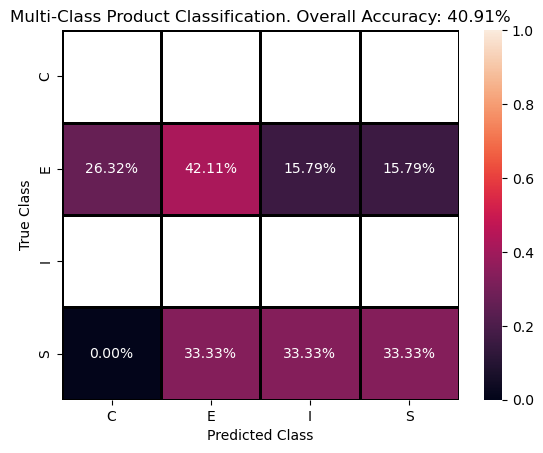

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 15 | B00DDMJ4PY   | S                 |               3 |                    3 | S                      |
|  1 | B003ARUHHQ   | S                 |               3 |                    2 | I                      |
|  7 | B01EKZO92U   | S                 |               3 |                    1 | E                      |
+----+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 124905


C:\Users\flash\AppData\Local\Temp\ipykernel_13660\1391113780.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


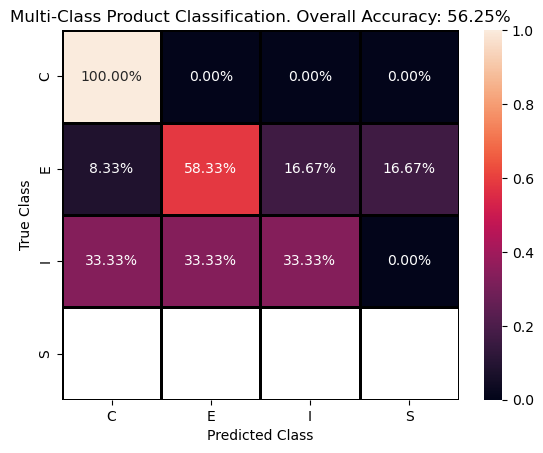

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+--------------+-------------------+-----------------+----------------------+------------------------+
| Prodcut_ID   | True Esci Label   | True Encoding   | Predicted Encoding   | Predicted Esci Label   |
|--------------+-------------------+-----------------+----------------------+------------------------|
+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 61836


C:\Users\flash\AppData\Local\Temp\ipykernel_13660\1391113780.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


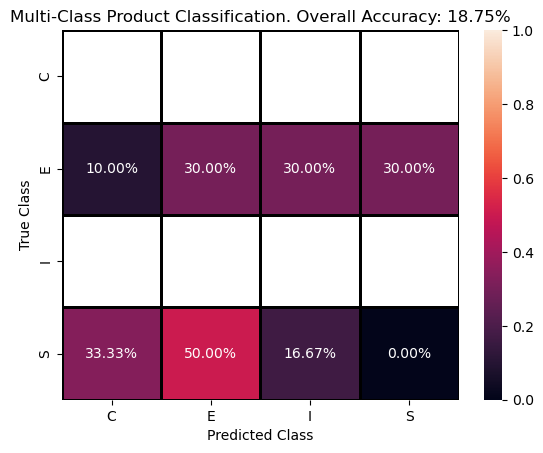

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
| 15 | B07X9KN32M   | S                 |               3 |                    2 | I                      |
| 12 | B083NTZM7P   | S                 |               3 |                    1 | E                      |
| 13 | B086S55CTF   | S                 |               3 |                    1 | E                      |
| 14 | B07SPY3LY7   | S                 |               3 |                    1 | E                      |
|  2 | B07RV5BHXR   | S                 |               3 |                    0 | C                      |
| 11 | B07ZZC5RTF   | S                 |

C:\Users\flash\AppData\Local\Temp\ipykernel_13660\1391113780.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


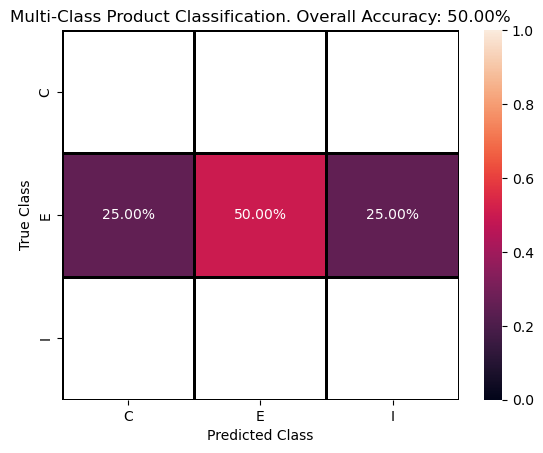

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+--------------+-------------------+-----------------+----------------------+------------------------+
| Prodcut_ID   | True Esci Label   | True Encoding   | Predicted Encoding   | Predicted Esci Label   |
|--------------+-------------------+-----------------+----------------------+------------------------|
+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------

Query ID: 22678


C:\Users\flash\AppData\Local\Temp\ipykernel_13660\1391113780.py:17: RuntimeWarning: invalid value encountered in divide
  cm = cm / np.sum(cm, axis = 1)[:, None]


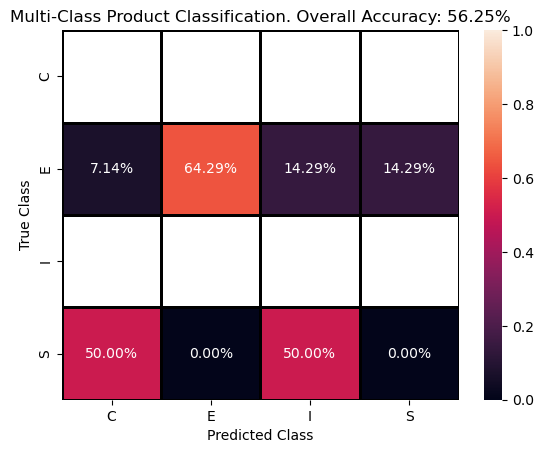

Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S
+----+--------------+-------------------+-----------------+----------------------+------------------------+
|    | Prodcut_ID   | True Esci Label   |   True Encoding |   Predicted Encoding | Predicted Esci Label   |
|----+--------------+-------------------+-----------------+----------------------+------------------------|
|  7 | B00CGVHJ32   | S                 |               3 |                    2 | I                      |
|  9 | B0863J1Y3H   | S                 |               3 |                    0 | C                      |
+----+--------------+-------------------+-----------------+----------------------+------------------------+

---------------------



In [7]:
from tabulate import tabulate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

query_ids = Large_Dataset.query_id.unique()
random_query_ids = np.random.choice(query_ids, size = 5, replace = False)


for query_id in random_query_ids:
    query_id_mask = Large_Dataset.loc[:, "query_id"] == query_id
    subset = Large_Dataset.loc[query_id_mask, :]
    print(f"Query ID: {query_id}")
    Result_df = Model.Task(subset)
    accuracy = np.mean(Result_df.loc[:, "Predicted Esci Label"] == Result_df.loc[:, "True Esci Label"])
    cm = confusion_matrix(y_true = Result_df["True Encoding"].to_numpy().astype(int), y_pred = Result_df["Predicted Encoding"].to_numpy().astype(int))
    cm = cm / np.sum(cm, axis = 1)[:, None]
    labels = pd.DataFrame(np.concatenate((Result_df.loc[:, ("True Esci Label", "True Encoding")].to_numpy(), Result_df.loc[:, ("Predicted Esci Label", "Predicted Encoding")].to_numpy()), axis = 0)).drop_duplicates().sort_values(by = [1]).iloc[:, 0]
    fig = plt.figure()
    ax = fig.add_subplot()
    sns.heatmap(cm, ax = ax, xticklabels = labels, yticklabels = labels, fmt = ".2%", annot = True, linewidths = 1, linecolor = "black", vmin = 0, vmax = 1)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_title(f"Multi-Class Product Classification. Overall Accuracy: {accuracy:.2%}")
    plt.show()
    
    substitute_mask = Result_df["True Esci Label"] == "S"
    S_df = Result_df.loc[substitute_mask, :]
    S_df = S_df.sort_values(by = ["Predicted Encoding"], ascending = False)
    print("Query-Product-Ranking and Multi-Class Product Classification specifically for the Esci Label S")
    print(tabulate(S_df, headers='keys', tablefmt='psql'))
    print("\n---------------------\n")